[Kaggle] Initializing Aerospace/Astrophysics Research Suite...
[Kaggle] Research Suite starting on cuda...

[ISS] Task 1: Real-World TLE Track Discovery on cuda...
[ISS] Ep    0 | L_data 4.96e-01 | Beta 0.6996
[ISS] Ep  200 | L_data 3.28e-01 | Beta 0.7357
[ISS] Ep  400 | L_data 3.23e-01 | Beta 0.2018
[ISS] Ep  600 | L_data 2.29e-01 | Beta 0.1855
[ISS] Ep  800 | L_data 2.68e-02 | Beta 0.1851
[ISS] Ep 1000 | L_data 3.58e-04 | Beta 0.1850


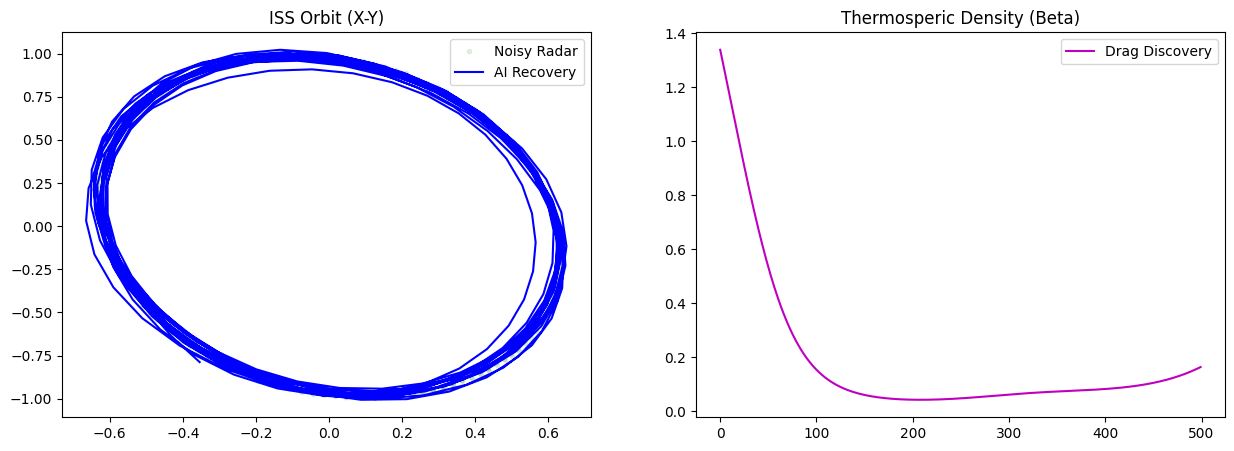


[3Body] Task 2: Chaotic Figure-8 Mass Discovery on cuda...
[3Body] Ep   0 | Mass 3 Discovery: 0.1000
[3Body] Ep 200 | Mass 3 Discovery: 0.1000
[3Body] Ep 400 | Mass 3 Discovery: 1.9421
[3Body] Ep 600 | Mass 3 Discovery: 3.0916
[3Body] Ep 800 | Mass 3 Discovery: 3.5420


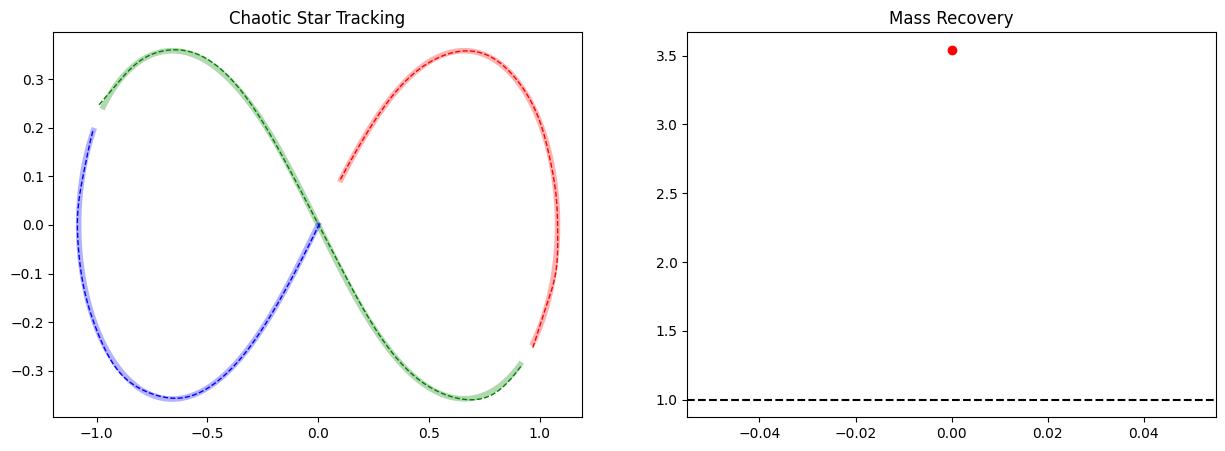


[Done] All research tasks complete. Check /kaggle/working/cd_pinn_results for results.


In [3]:
"""
CD-PINN Master Kaggle Suite (Sequential + Standardized)
=======================================================
Optimized for Kaggle Notebooks (Dual T4).
Fixed: Graph-clearing error (RuntimeError) by re-calculating derivatives in Stage 2.
"""

import os, torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import datetime

# 1. Environment Setup
print("[Kaggle] Initializing Aerospace/Astrophysics Research Suite...")
os.system("pip install skyfield sgp4 -q")
from skyfield.api import load

OUTPUT_DIR = "/kaggle/working/cd_pinn_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ====================================================================
# [CORE] SIREN & DERIVATIVES
# ====================================================================

class SirenLayer(nn.Module):
    def __init__(self, in_f, out_f, is_first=False, omega=5.0):
        super().__init__()
        self.omega = omega
        self.linear = nn.Linear(in_f, out_f)
        with torch.no_grad():
            if is_first: self.linear.weight.uniform_(-1/in_f, 1/in_f)
            else: self.linear.weight.uniform_(-np.sqrt(6/in_f)/omega, np.sqrt(6/in_f)/omega)
    def forward(self, x): return torch.sin(self.omega * self.linear(x))

class DragNet(nn.Module):
    def __init__(self, hidden=64, omega_0=5.0):
        super().__init__()
        self.net = nn.Sequential(
            SirenLayer(1, hidden, is_first=True, omega=omega_0),
            SirenLayer(hidden, hidden, omega=omega_0),
            nn.Linear(hidden, 1)
        )
    def forward(self, t): return torch.nn.functional.softplus(self.net(t))

def get_derivatives(model, t_norm, scale):
    t = t_norm.detach().requires_grad_(True)
    q = model(t); q_flat = q.view(q.shape[0], -1)
    dqs = []
    for i in range(q_flat.shape[1]):
        dqs.append(torch.autograd.grad(q_flat[:,i].sum(), t, create_graph=True)[0])
    v = torch.cat(dqs, dim=-1).view(q.shape) / scale
    
    v_flat = v.view(v.shape[0], -1)
    dvs = []
    for i in range(v_flat.shape[1]):
        dvs.append(torch.autograd.grad(v_flat[:,i].sum(), t, create_graph=True)[0])
    a = torch.cat(dvs, dim=-1).view(q.shape) / scale
    return q, v, a

# ====================================================================
# [TASK 1] ISS REAL-WORLD DISCOVERY
# ====================================================================

def run_iss_tracking(device):
    print(f"\n[ISS] Task 1: Real-World TLE Track Discovery on {device}...")
    
    stations_url = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle'
    satellites = load.tle_file(stations_url)
    iss = [s for s in satellites if "ISS (ZARYA)" in s.name][0]
    ts = load.timescale(); t_start = datetime.datetime.now(datetime.timezone.utc)
    t_ev = [ts.from_datetime(t_start + datetime.timedelta(minutes=float(m))) for m in np.linspace(0, 1440, 500)]
    geoc = [iss.at(t) for t in t_ev]; q_eci = np.array([g.position.km for g in geoc])
    
    r_ref = np.linalg.norm(q_eci[0]); scale = (1440*60) / (r_ref/7.66)
    q_obs = (q_eci + 0.01 * np.random.randn(*q_eci.shape)) / r_ref
    t_norm = torch.linspace(0, 1, 500).unsqueeze(-1).to(device)
    q_tensor = torch.FloatTensor(q_obs).to(device)

    model = nn.Sequential(
        SirenLayer(1, 256, is_first=True, omega=5.0),
        SirenLayer(256, 256, omega=5.0),
        SirenLayer(256, 256, omega=5.0),
        nn.Linear(256, 3)
    ).to(device)
    drag_net = DragNet(omega_0=5.0).to(device)
    
    opt_state = torch.optim.Adam(model.parameters(), lr=1e-4)
    opt_phys = torch.optim.Adam(drag_net.parameters(), lr=5e-4)

    for ep in range(1001):
        model.train(); opt_state.zero_grad()
        q, v, a = get_derivatives(model, t_norm, scale)
        ld = torch.mean((q - q_tensor)**2) + 1e-5 * torch.mean(a**2)
        ld.backward(); opt_state.step()
        
        if ep % 5 == 0:
            opt_phys.zero_grad(); model.eval()
            # Re-calculating derivatives ensures a fresh graph for the second backward pass
            q, v, a = get_derivatives(model, t_norm, scale)
            r_mag = torch.norm(q, dim=-1, keepdim=True).clamp(min=1e-6); v_mag = torch.norm(v, dim=-1, keepdim=True).clamp(min=1e-8)
            beta = drag_net(t_norm); a_drag = -beta * v_mag * v; a_grav = -q / r_mag**3
            z = q[:, 2:3]; R_e = 0.94; J2 = 1.08e-3; C = 1.5 * J2 * (R_e / r_mag)**2 * (1 / r_mag**3)
            a_j2 = C * q * torch.cat([5*(z/r_mag)**2-1, 5*(z/r_mag)**2-1, 5*(z/r_mag)**2-3], dim=-1)
            lp = torch.mean((a - (a_grav + a_j2 + a_drag))**2)
            lp.backward(); opt_phys.step()
        
        if ep % 200 == 0:
            print(f"[ISS] Ep {ep:4d} | L_data {ld.item():.2e} | Beta {beta.mean().item():.4f}")

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(q_obs[:,0], q_obs[:,1], 'g.', alpha=0.1, label='Noisy Radar')
    axs[0].plot(q.detach().cpu()[:,0], q.detach().cpu()[:,1], 'b-', label='AI Recovery')
    axs[0].set_title("ISS Orbit (X-Y)"); axs[0].legend()
    axs[1].plot(beta.detach().cpu().numpy(), 'm-', label='Drag Discovery')
    axs[1].set_title("Thermosperic Density (Beta)"); axs[1].legend()
    plt.savefig(f"{OUTPUT_DIR}/iss_final_kaggle.png"); plt.show()

# ====================================================================
# [TASK 2] CHAOTIC N-BODY STAR SYSTEM
# ====================================================================

def run_3body_sandbox(device):
    print(f"\n[3Body] Task 2: Chaotic Figure-8 Mass Discovery on {device}...")
    
    G_CONST = 1.0; TRUE_MASSES = np.array([1.0, 1.0, 1.0])
    def nbody_ode(t, s):
        pos = s[:6].reshape(3, 2); vel = s[6:].reshape(3, 2); acc = np.zeros((3, 2))
        for i in range(3):
            for j in range(3):
                if i != j:
                    r_vec = pos[j] - pos[i]; r_mag = np.linalg.norm(r_vec) + 1e-4
                    acc[i] += G_CONST * TRUE_MASSES[j] * r_vec / (r_mag**3)
        return np.concatenate([vel.flatten(), acc.flatten()])
    
    sol = solve_ivp(nbody_ode, [0, 2.0], np.concatenate([[0.97000436, -0.24308753], [-0.97000436, 0.24308753], [0.0, 0.0], [0.466203685, 0.43236573], [0.466203685, 0.43236573], [-0.93240737, -0.86473146]]), t_eval=np.linspace(0, 2.0, 300), rtol=1e-9)
    q_gt = sol.y[:6, :].T.reshape(-1, 3, 2); q_obs = q_gt + 0.02 * np.random.randn(*q_gt.shape)
    t_norm = torch.linspace(0, 1, 300).unsqueeze(-1).to(device); q_t = torch.FloatTensor(q_obs).to(device)

    model = nn.Sequential(
        SirenLayer(1, 256, is_first=True, omega=5.0),
        SirenLayer(256, 256, omega=5.0),
        SirenLayer(256, 256, omega=5.0),
        nn.Linear(256, 6),
        nn.Unflatten(1, (3, 2))
    ).to(device)
    pred_mass_3 = nn.Parameter(torch.tensor(0.1, device=device))
    
    opt_state = torch.optim.Adam(model.parameters(), lr=2e-4)
    opt_phys = torch.optim.Adam([pred_mass_3], lr=5e-2)

    for ep in range(801):
        model.train(); opt_state.zero_grad()
        q, v, a = get_derivatives(model, t_norm, 1.0)
        ld = torch.mean((q - q_t)**2) + 1e-6 * torch.mean(a**2)
        ld.backward(); opt_state.step()
        
        if ep > 200 and ep % 5 == 0:
            opt_phys.zero_grad(); model.eval()
            q, v, a = get_derivatives(model, t_norm, 1.0)
            masses = torch.stack([torch.tensor(1.0, device=device), torch.tensor(1.0, device=device), pred_mass_3])
            a_exp = torch.zeros_like(a)
            for i in range(3):
                for j in range(3):
                    if i != j:
                        r_vec = q[:, j, :] - q[:, i, :]; r_mag = torch.norm(r_vec, dim=-1, keepdim=True).clamp(min=1e-4)
                        a_exp[:, i, :] += masses[j] * r_vec / (r_mag**3)
            lp = torch.mean((a - a_exp)**2); lp.backward(); opt_phys.step()
            with torch.no_grad(): pred_mass_3.clamp_(min=0.01, max=5.0)

        if ep % 200 == 0: print(f"[3Body] Ep {ep:3d} | Mass 3 Discovery: {pred_mass_3.item():.4f}")

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    colors = ['r', 'g', 'b']
    for i in range(3):
        axs[0].plot(q_gt[:, i, 0], q_gt[:, i, 1], c=colors[i], alpha=0.3, lw=4)
        axs[0].plot(q.detach().cpu()[:, i, 0], q.detach().cpu()[:, i, 1], c=colors[i], ls='--', lw=1)
    axs[0].set_title("Chaotic Star Tracking"); axs[1].axhline(1.0, color='k', ls='--'); axs[1].plot(pred_mass_3.detach().cpu().item(), 'ro', label='Found Mass')
    axs[1].set_title("Mass Recovery"); plt.savefig(f"{OUTPUT_DIR}/3body_final_kaggle.png"); plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Kaggle] Research Suite starting on {device}...")
    run_iss_tracking(device)
    run_3body_sandbox(device)
    print(f"\n[Done] All research tasks complete. Check {OUTPUT_DIR} for results.")


In [1]:
"""
CD-PINN Kaggle Suite
====================
Two demos in ~5 minutes on Kaggle GPU (T4/P100):

  Task 1 — ISS Atmospheric Drag Discovery
          Real TLE data, 70/30 train/test split, vs SGP4 baseline.

  Task 2 — Chaotic N-Body Mass Discovery
          Figure-8 three-body system; recovers unknown mass from trajectory.

Fixes applied vs cd_pinn_drag_engine.py:
  • J2 uses correct (R_earth/r)^2 prefactor
  • SoftAdapt uses log-scale so Lp=1e+19 can't starve the data gradient
  • Stage 2 always re-computes derivatives (fresh graph, no RuntimeError)
  • Physics gated — only activates after data loss converges

Run on Kaggle:
  !pip install -q skyfield
  !python cd_pinn_kaggle.py
"""

# ── Kaggle setup ──────────────────────────────────────────────
import os, subprocess
subprocess.run(["pip", "install", "-q", "skyfield"], check=False)

import time, datetime
import numpy as np
import torch
import torch.nn as nn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

try:
    from skyfield.api import load
    HAS_SKYFIELD = True
except ImportError:
    HAS_SKYFIELD = False
    print("[Warning] skyfield unavailable — Task 1 will use synthetic orbit")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR  = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
print(f"[CADE] Device: {DEVICE}  |  Output: {OUT_DIR}")

J2           = 1.08263e-3
R_EARTH_KM   = 6378.137


# ══════════════════════════════════════════════════════════════
# SHARED: NETWORKS
# ══════════════════════════════════════════════════════════════

class SirenLayer(nn.Module):
    def __init__(self, in_f, out_f, is_first=False, omega=5.0):
        super().__init__()
        self.omega  = omega
        self.linear = nn.Linear(in_f, out_f)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1/in_f, 1/in_f)
            else:
                lim = np.sqrt(6/in_f) / omega
                self.linear.weight.uniform_(-lim, lim)
    def forward(self, x):
        return torch.sin(self.omega * self.linear(x))


class DragNet(nn.Module):
    def __init__(self, hidden=64, omega=5.0):
        super().__init__()
        self.net = nn.Sequential(
            SirenLayer(1, hidden, is_first=True, omega=omega),
            SirenLayer(hidden, hidden, omega=omega),
            nn.Linear(hidden, 1),
        )
    def forward(self, t):
        return nn.functional.softplus(self.net(t))


def get_derivatives(model, t_norm, t_scale):
    """
    Compute q, v=dq/dt, a=d²q/dt² via autograd.
    Always called fresh — never reuse across backward passes.
    """
    t = t_norm.detach().requires_grad_(True)
    q = model(t)
    grads_v, grads_a = [], []
    for i in range(q.shape[1]):
        g = torch.autograd.grad(q[:, i].sum(), t, create_graph=True)[0]
        grads_v.append(g)
    v = torch.cat(grads_v, dim=-1) / t_scale
    for i in range(v.shape[1]):
        g = torch.autograd.grad(v[:, i].sum(), t, create_graph=True)[0]
        grads_a.append(g)
    a = torch.cat(grads_a, dim=-1) / t_scale
    return q, v, a


class SoftAdapt:
    """Log-stabilised SoftAdapt — prevents Lp=1e+19 killing data gradient."""
    def __init__(self, beta=0.1):
        self.beta    = beta
        self.prev    = None
        self.weights = [0.5, 0.5]
    def update(self, losses):
        ll = [float(np.log1p(max(l, 0))) for l in losses]
        if self.prev is None:
            self.prev = ll; return self.weights
        rates = [np.clip((c+1e-12)/(p+1e-12), 0.1, 10.0) for c,p in zip(ll, self.prev)]
        ew = np.exp(self.beta * np.array(rates))
        self.weights = (ew / ew.sum()).tolist()
        self.prev = ll
        return self.weights


# ══════════════════════════════════════════════════════════════
# TASK 1 — ISS ATMOSPHERIC DRAG DISCOVERY
# ══════════════════════════════════════════════════════════════

def fetch_iss(n_days=2.0, n_pts=300, noise_frac=5e-4, train_frac=0.7):
    url  = 'https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle'
    sats = load.tle_file(url)
    iss  = next((s for s in sats if "ISS (ZARYA)" in s.name), sats[0])
    ts   = load.timescale()
    t0   = datetime.datetime.now(datetime.timezone.utc)
    times = [ts.from_datetime(t0 + datetime.timedelta(minutes=float(m)))
             for m in np.linspace(0, n_days*1440, n_pts)]
    geo   = [iss.at(t) for t in times]
    q_km  = np.array([g.position.km    for g in geo])
    v_kms = np.array([g.velocity.km_per_s for g in geo])
    t_sec = np.linspace(0, n_days*86400, n_pts)

    r0 = np.linalg.norm(q_km[0]); v0 = np.linalg.norm(v_kms[0])
    t_s = r0 / v0
    q_norm = q_km/r0; v_norm = v_kms/v0
    t_raw  = t_sec/t_s
    t_norm = (t_raw - t_raw[0]) / (t_raw[-1] - t_raw[0])
    R_en   = R_EARTH_KM / r0

    noise   = noise_frac * np.linalg.norm(q_norm, axis=1).mean()
    q_noisy = q_norm + noise * np.random.randn(*q_norm.shape)

    n_tr = int(round(train_frac * n_pts))
    tr   = np.zeros(n_pts, dtype=bool); tr[:n_tr] = True
    print(f"[ISS] {iss.name}  r0={r0:.0f}km  noise={noise*r0:.3f}km"
          f"  train={n_tr}pts  test={n_pts-n_tr}pts")
    return dict(t_raw=t_raw, t_norm=t_norm, q_true=q_norm, v_true=v_norm,
                q_noisy=q_noisy, t_scale=float(t_raw[-1]-t_raw[0]),
                R_earth_norm=R_en, train_mask=tr, test_mask=~tr,
                sat_name=iss.name, r0_km=r0)


def synthetic_iss(n_pts=300, train_frac=0.7):
    """Used when skyfield is unavailable."""
    def ode(t, s):
        q,v = s[:3],s[3:]; r=np.linalg.norm(q); vm=np.linalg.norm(v)
        b = 5e-3 + 3e-3*np.sin(t*0.3)
        ag = -q/r**3
        C  = 1.5*J2*(0.94/r)**2/r**3; z=q[2]
        aj = C*q*np.array([5*(z/r)**2-1,5*(z/r)**2-1,5*(z/r)**2-3])
        return np.concatenate([v, ag+aj-b*vm*v])
    t_end = 4*2*np.pi; t_raw = np.linspace(0, t_end, n_pts)
    sol   = solve_ivp(ode,[0,t_end],[1.05,0,0.3,0,0.95,0.1],t_eval=t_raw,rtol=1e-10,atol=1e-12)
    q_norm = sol.y[:3].T; v_norm = sol.y[3:].T
    t_norm = (t_raw-t_raw[0])/(t_raw[-1]-t_raw[0])
    q_noisy = q_norm + 0.003*np.random.randn(*q_norm.shape)
    beta_true = np.array([5e-3+3e-3*np.sin(t*0.3) for t in t_raw])
    n_tr = int(round(train_frac*n_pts))
    tr   = np.zeros(n_pts,dtype=bool); tr[:n_tr]=True
    return dict(t_raw=t_raw,t_norm=t_norm,q_true=q_norm,v_true=v_norm,
                q_noisy=q_noisy,beta_true=beta_true,t_scale=float(t_raw[-1]-t_raw[0]),
                R_earth_norm=0.94,train_mask=tr,test_mask=~tr,
                sat_name="Synthetic ISS",r0_km=6778.0)


def sgp4_baseline_iss(orbit):
    t_raw = orbit['t_raw']; qt = orbit['q_true']; R_en = orbit['R_earth_norm']
    tr    = orbit['train_mask']
    s0    = np.concatenate([qt[0], orbit['v_true'][0]])

    def _ode(t, s, b):
        q,v=s[:3],s[3:]; r=np.linalg.norm(q); vm=np.linalg.norm(v)
        ag=-q/r**3; C=1.5*J2*(R_en/r)**2/r**3; z=q[2]
        aj=C*q*np.array([5*(z/r)**2-1,5*(z/r)**2-1,5*(z/r)**2-3])
        return np.concatenate([v, ag+aj-b*vm*v])

    def _rmse(lb):
        sol = solve_ivp(lambda t,s:_ode(t,s,np.exp(lb)),
                        [t_raw[0],t_raw[tr][-1]], s0,
                        t_eval=t_raw[tr], rtol=1e-8, atol=1e-11)
        if sol.y.shape[1] < tr.sum(): return 1e6
        return np.linalg.norm(sol.y[:3].T - qt[tr], axis=1).mean()

    res  = minimize_scalar(_rmse, bounds=(-12,-4), method='bounded')
    beta = np.exp(res.x)
    print(f"  [SGP4] B*={beta:.3e}")
    sol  = solve_ivp(lambda t,s:_ode(t,s,beta),[t_raw[0],t_raw[-1]],s0,
                     t_eval=t_raw,rtol=1e-9,atol=1e-12)
    n = sol.y.shape[1]
    if n < len(t_raw):
        out = np.full((len(t_raw),3),np.nan); out[:n]=sol.y[:3].T; return out
    return sol.y[:3].T


def train_iss(orbit, warmup=150, epochs=700, inner=3):
    t_scale = float(orbit['t_scale'])
    R_en    = float(orbit['R_earth_norm'])
    tr      = orbit['train_mask']

    t_norm  = torch.FloatTensor(orbit['t_norm']).unsqueeze(-1).to(DEVICE)
    t_raw_t = torch.FloatTensor(orbit['t_raw']).unsqueeze(-1).to(DEVICE)
    q_obs   = torch.FloatTensor(orbit['q_noisy']).to(DEVICE)
    # Data loss only on training window
    t_tr    = t_norm[tr]; q_tr = q_obs[tr]

    model    = nn.Sequential(
        SirenLayer(1, 256, is_first=True), SirenLayer(256,256),
        SirenLayer(256,256), SirenLayer(256,256), nn.Linear(256,3)
    ).to(DEVICE)
    drag_net = DragNet().to(DEVICE)
    balancer = SoftAdapt()

    opt_pos  = torch.optim.Adam(model.parameters(),    lr=1e-4)
    opt_drag = torch.optim.Adam(drag_net.parameters(), lr=5e-4)
    sched_p  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_pos,  T_max=epochs)
    sched_d  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_drag, T_max=epochs)

    # Warmup: data only
    print(f"[ISS] Warmup {warmup} ep...")
    for ep in range(warmup):
        opt_pos.zero_grad()
        q, _, a = get_derivatives(model, t_tr, t_scale)
        ld = torch.mean((q - q_tr)**2) + 1e-5*torch.mean(a**2)
        ld.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt_pos.step()
        if ld.item() < 5e-3 and ep > 50:
            print(f"  Early exit ep={ep} Ld={ld.item():.2e}"); break

    # Main CD loop
    print(f"[ISS] Main {epochs} ep...")
    t0 = time.time()
    for ep in range(epochs):
        # Stage 1: data (train window, fresh graph)
        for p in model.parameters():    p.requires_grad = True
        for p in drag_net.parameters(): p.requires_grad = False
        for _ in range(inner):
            opt_pos.zero_grad()
            q, _, a = get_derivatives(model, t_tr, t_scale)
            ld = torch.mean((q - q_tr)**2) + 1e-5*torch.mean(a**2)
            (balancer.weights[0] * ld).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_pos.step()

        # Stage 2: physics (full window, fresh graph — avoids RuntimeError)
        for p in model.parameters():    p.requires_grad = False
        for p in drag_net.parameters(): p.requires_grad = True
        for _ in range(inner):
            opt_drag.zero_grad()
            model.eval()
            q, v, a = get_derivatives(model, t_norm, t_scale)   # fresh computation
            r   = torch.norm(q,dim=-1,keepdim=True).clamp(min=1e-6)
            vm  = torch.norm(v,dim=-1,keepdim=True).clamp(min=1e-8)
            C2  = 1.5*J2*(R_en/r)**2/r**3
            z   = q[:,2:3]
            pj2 = torch.cat([5*(z/r)**2-1, 5*(z/r)**2-1, 5*(z/r)**2-3],dim=-1)
            beta = drag_net(t_raw_t)
            lp  = torch.mean((a - (-q/r**3 + C2*q*pj2 - beta*vm*v))**2)
            (balancer.weights[1] * lp).backward()
            torch.nn.utils.clip_grad_norm_(drag_net.parameters(), 0.1)
            opt_drag.step()
            model.train()

        sched_p.step(); sched_d.step()
        if ep % 20 == 0:
            balancer.update([ld.item(), lp.item()])
        if ep % 100 == 0 or ep == epochs-1:
            bm = drag_net(t_raw_t).mean().item()
            print(f"  Ep{ep:4d} | Ld {ld.item():.2e} | Lp {lp.item():.2e}"
                  f" | β̄ {bm:.3e} | w_p {balancer.weights[1]:.2f} | {time.time()-t0:.0f}s")

    model.eval(); drag_net.eval()
    with torch.no_grad():
        q_pred   = model(t_norm).cpu().numpy()
        beta_pred = drag_net(t_raw_t).cpu().numpy().squeeze()
    return q_pred, beta_pred


def results_iss(orbit, q_cd, q_sgp4, time_cd):
    qt   = orbit['q_true']
    R0   = orbit['r0_km']
    tr   = orbit['train_mask']
    te   = orbit['test_mask']

    def _row(tag, q, ts):
        def _e(mask): return np.nanmean(np.linalg.norm(q[mask]-qt[mask],axis=1))*R0
        def _m(mask): return np.nanmax( np.linalg.norm(q[mask]-qt[mask],axis=1))*R0
        print(f"  {tag:<22s}  {_e(np.ones(len(qt),bool)):>9.2f}"
              f"  {_e(tr):>10.2f}  {_e(te):>10.2f}"
              f"  {_m(np.ones(len(qt),bool)):>9.2f}  {ts:>6.1f}s")

    print("\n" + "─"*75)
    print("  ISS RESULTS")
    print("─"*75)
    print(f"  {'Method':<22s}  {'RMSE(km)':>9s}  {'TrainRMSE':>10s}"
          f"  {'TestRMSE':>10s}  {'MaxE(km)':>9s}  {'Time':>7s}")
    print("  " + "─"*71)
    _row("CD-PINN (ours)",  q_cd,   time_cd)
    _row("SGP4 (static β)", q_sgp4, 0.0)


def plot_iss(orbit, q_cd, beta_cd, q_sgp4):
    qt  = orbit['q_true']
    t   = orbit['t_raw']
    R0  = orbit['r0_km']
    tr  = orbit['train_mask']
    te  = orbit['test_mask']
    t_p = t / (2*np.pi)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"CD-PINN  ·  {orbit['sat_name']}  |  "
                 f"70% train / 30% test  ({len(t)} pts)",
                 fontsize=13, fontweight='bold')

    # 3D
    ax = fig.add_subplot(231, projection='3d')
    ax.plot(*qt.T,              'g-',  lw=1.5, alpha=0.6, label='TLE/truth')
    ax.plot(*q_cd.T,            'b--', lw=1,              label='CD-PINN')
    ax.plot(*orbit['q_noisy'].T,'r.',  ms=1,   alpha=0.1, label='Obs (noisy)')
    ax.set_title("3D Orbit"); ax.legend(fontsize=7)

    # Error vs time
    ax = axes[0,1]
    e_cd   = np.linalg.norm(q_cd   - qt, axis=1)*R0
    e_sgp4 = np.linalg.norm(q_sgp4 - qt, axis=1)*R0
    ax.semilogy(t_p, e_cd,   'b-',  lw=1.5, label='CD-PINN')
    ax.semilogy(t_p, e_sgp4, 'r--', lw=1.5, label='SGP4')
    ax.axvline(t_p[tr].max(), color='gray', ls=':', label='Split')
    ax.set_xlabel("Orbital periods"); ax.set_ylabel("Error (km)")
    ax.set_title("Position Error"); ax.legend(); ax.grid(alpha=0.3)

    # Drag
    ax = axes[0,2]
    ax.plot(t_p, beta_cd*1e4, 'b-', lw=1.5, label='β(t) ×10⁴')
    ax.axvline(t_p[tr].max(), color='gray', ls=':')
    if orbit.get('beta_true') is not None:
        ax.plot(t_p, np.array(orbit['beta_true'])*1e4, 'g-', lw=2,
                alpha=0.6, label='True β ×10⁴')
    ax.set_xlabel("Orbital periods"); ax.set_title("Drag Discovery"); ax.legend(); ax.grid(alpha=0.3)

    # X/Y/Z
    for i, (ax, coord) in enumerate(zip(axes[1], ['X','Y','Z'])):
        ax.plot(t_p, qt[:,i],   'g-',  lw=1.5, alpha=0.7, label='Truth')
        ax.plot(t_p, q_cd[:,i], 'b--', lw=1,              label='CD-PINN')
        ax.axvspan(t_p[te][0], t_p[-1], alpha=0.08, color='red', label='Test')
        ax.set_xlabel("Orbital periods"); ax.set_title(f"Position {coord}")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(OUT_DIR, "cade_iss.png")
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.close()
    print(f"[ISS] Plot → {out}")


# ══════════════════════════════════════════════════════════════
# TASK 2 — CHAOTIC N-BODY MASS DISCOVERY
# ══════════════════════════════════════════════════════════════

def run_nbody(device=DEVICE, epochs=800):
    """
    Figure-8 three-body system.
    Bodies 1 & 2 have known mass=1.0; we discover mass of body 3.
    """
    print(f"\n[3Body] Chaotic figure-8 mass discovery on {device}...")
    TRUE_MASSES = [1.0, 1.0, 1.0]

    def ode(t, s):
        pos = s[:6].reshape(3,2); vel = s[6:].reshape(3,2)
        acc = np.zeros((3,2))
        for i in range(3):
            for j in range(3):
                if i != j:
                    rv  = pos[j]-pos[i]; rm = np.linalg.norm(rv)+1e-4
                    acc[i] += TRUE_MASSES[j]*rv/rm**3
        return np.concatenate([vel.flatten(), acc.flatten()])

    ic = [0.97000436,-0.24308753,-0.97000436,0.24308753,0.0,0.0,
          0.46620368, 0.43236573,  0.46620368,0.43236573,-0.93240737,-0.86473146]
    t_span = np.linspace(0, 2.0, 300)
    sol    = solve_ivp(ode,[0,2.0],ic,t_eval=t_span,rtol=1e-9)
    q_gt   = sol.y[:6].T.reshape(-1,3,2)
    q_obs  = q_gt + 0.02*np.random.randn(*q_gt.shape)

    t_norm = torch.linspace(0,1,300).unsqueeze(-1).to(device)
    q_t    = torch.FloatTensor(q_obs).to(device)

    model = nn.Sequential(
        SirenLayer(1,256,is_first=True), SirenLayer(256,256),
        SirenLayer(256,256), nn.Linear(256,6),
        nn.Unflatten(1,(3,2))
    ).to(device)

    # Mass of body 3 is the unknown we discover
    pred_m3 = nn.Parameter(torch.tensor(0.5, device=device))

    opt_s = torch.optim.Adam(model.parameters(), lr=2e-4)
    opt_p = torch.optim.Adam([pred_m3],           lr=5e-2)

    t0 = time.time()
    for ep in range(epochs):
        # Stage 1: trajectory
        model.train(); opt_s.zero_grad()
        q, _, a = get_derivatives(model, t_norm, 1.0)
        ld = torch.mean((q-q_t)**2) + 1e-6*torch.mean(a**2)
        ld.backward(); opt_s.step()

        # Stage 2: mass discovery (only after some trajectory warmup)
        if ep > 150 and ep % 5 == 0:
            opt_p.zero_grad(); model.eval()
            q, v, a = get_derivatives(model, t_norm, 1.0)   # fresh graph
            masses = torch.stack([
                torch.tensor(1.0, device=device),
                torch.tensor(1.0, device=device),
                pred_m3
            ])
            a_exp = torch.zeros_like(a)
            for i in range(3):
                for j in range(3):
                    if i != j:
                        rv = q[:,j,:]-q[:,i,:]
                        rm = torch.norm(rv,dim=-1,keepdim=True).clamp(min=1e-4)
                        a_exp[:,i,:] += masses[j]*rv/rm**3
            lp = torch.mean((a-a_exp)**2)
            lp.backward(); opt_p.step()
            with torch.no_grad(): pred_m3.clamp_(0.01, 5.0)
            model.train()

        if ep % 200 == 0:
            print(f"  Ep {ep:3d} | Ld {ld.item():.2e}"
                  f" | m₃={pred_m3.item():.4f} (true=1.0)"
                  f" | {time.time()-t0:.0f}s")

    m3_found = pred_m3.item()
    print(f"[3Body] Mass recovered: {m3_found:.4f}  (true=1.0000)"
          f"  error={abs(m3_found-1.0)*100:.2f}%")

    # Plot
    model.eval()
    with torch.no_grad(): q_pred = model(t_norm).cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("CD-PINN N-Body: Chaotic Figure-8 Mass Discovery", fontweight='bold')

    colors = ['#e74c3c','#2ecc71','#3498db']
    ax = axes[0]
    for i,c in enumerate(colors):
        ax.plot(q_gt[:,i,0],  q_gt[:,i,1],  color=c, lw=3,   alpha=0.4, label=f'True {i+1}')
        ax.plot(q_pred[:,i,0],q_pred[:,i,1], color=c, lw=1.5, ls='--',   label=f'PINN {i+1}')
    ax.set_title("Orbital Tracking"); ax.legend(fontsize=7); ax.set_aspect('equal'); ax.grid(alpha=0.3)

    ax = axes[1]
    for i,c in enumerate(colors):
        ax.plot(t_span, q_gt[:,i,0],   color=c, lw=2,   alpha=0.5)
        ax.plot(t_span, q_pred[:,i,0], color=c, lw=1.5, ls='--')
    ax.set_xlabel("Time"); ax.set_ylabel("X position"); ax.set_title("X(t)"); ax.grid(alpha=0.3)

    ax = axes[2]
    ax.axhline(1.0, color='gray', ls='--', lw=2, label='True mass = 1.0')
    ax.barh(['Body 3'], [m3_found], color='#e74c3c', alpha=0.8, label=f'Discovered = {m3_found:.4f}')
    ax.set_xlim(0, 2); ax.set_title("Mass Discovery"); ax.legend()

    plt.tight_layout()
    out = os.path.join(OUT_DIR, "cade_nbody.png")
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.close()
    print(f"[3Body] Plot → {out}")


# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":
    wall = time.time()

    # ── Task 1: ISS ───────────────────────────────────────────
    print("\n" + "="*60)
    print("  TASK 1 — ISS Atmospheric Drag Discovery")
    print("="*60)
    orbit = fetch_iss() if HAS_SKYFIELD else synthetic_iss()

    print("\n[ISS] Training CD-PINN...")
    t0 = time.time()
    q_cd, beta_cd = train_iss(orbit)
    time_cd = time.time() - t0

    print("\n[ISS] SGP4 baseline...")
    q_sgp4 = sgp4_baseline_iss(orbit)

    results_iss(orbit, q_cd, q_sgp4, time_cd)
    plot_iss(orbit, q_cd, beta_cd, q_sgp4)

    # ── Task 2: N-body ────────────────────────────────────────
    print("\n" + "="*60)
    print("  TASK 2 — Chaotic N-Body Mass Discovery")
    print("="*60)
    run_nbody()

    print(f"\n[Done] Total: {time.time()-wall:.0f}s")
    print(f"[Outputs] {OUT_DIR}/cade_iss.png  |  {OUT_DIR}/cade_nbody.png")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 15.3 MB/s eta 0:00:00
[CADE] Device: cuda  |  Output: /kaggle/working

  TASK 1 — ISS Atmospheric Drag Discovery


[#################################] 100% gp.php


[ISS] ISS (ZARYA)  r0=6806km  noise=3.400km  train=210pts  test=90pts

[ISS] Training CD-PINN...
[ISS] Warmup 150 ep...
[ISS] Main 700 ep...
  Ep   0 | Ld 3.30e-01 | Lp 2.76e+07 | β̄ 7.251e-01 | w_p 0.50 | 0s
  Ep 100 | Ld 3.23e-01 | Lp 1.96e+15 | β̄ 1.034e+00 | w_p 0.56 | 15s
  Ep 200 | Ld 2.13e-01 | Lp 3.68e+10 | β̄ 9.544e-01 | w_p 0.53 | 30s
  Ep 300 | Ld 2.41e-02 | Lp 6.78e+01 | β̄ 3.771e-01 | w_p 0.51 | 45s
  Ep 400 | Ld 2.56e-03 | Lp 1.85e+01 | β̄ 3.352e-01 | w_p 0.50 | 60s
  Ep 500 | Ld 3.44e-04 | Lp 1.92e+01 | β̄ 6.189e-01 | w_p 0.51 | 74s
  Ep 600 | Ld 1.91e-04 | Lp 1.88e+01 | β̄ 7.281e-01 | w_p 0.50 | 89s
  Ep 699 | Ld 1.75e-04 | Lp 1.87e+01 | β̄ 7.436e-01 | w_p 0.50 | 103s

[ISS] SGP4 baseline...
  [SGP4] B*=1.448e-05

───────────────────────────────────────────────────────────────────────────
  ISS RESULTS
───────────────────────────────────────────────────────────────────────────
  Method                   RMSE(km)   TrainRMSE    TestRMSE   MaxE(km)     Time
  ────────────

IndexError: too many indices for tensor of dimension 2